<a href="https://colab.research.google.com/github/youkjang/noaa-gefs-data/blob/main/notebooks/3_GEFS_lead_time_Ensemble_Spread.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NOAA Global Ensemble Forecast System (GEFS) from Amazon S3
###GEFS Ensemble Spread Growth with Forecast Lead Time

- Initial date: May 17, 2026
- Forecast lead time: 0, 24, 48, 72, 96, 120 hrs

###1. Install pacakges

In [1]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs fsspec

In [2]:
!pip install cartopy

###2.Import Libraries

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import s3fs
from pathlib import Path

In [4]:
import cartopy.crs as ccrs

###3.Set GEFS case information

In [5]:
# Forecast initialization
init_date = "20260517"   # YYYYMMDD
cycle = "00"             # 00, 06, 12, 18 UTC

# Forecast lead times: 0 to 5 days
fhrs = [0, 24, 48, 72, 96, 120]

# Starter ensemble: control + 10 perturbed members
members = ["c00"] + [f"p{i:02d}" for i in range(1, 11)]

# Local cache directory in Colab
cache_dir = Path("/content/gefs_cache")
cache_dir.mkdir(exist_ok=True)

# Anonymous access to NOAA GEFS AWS bucket
fs = s3fs.S3FileSystem(anon=True)

###4.Function to open one GEFS member and forecast hour

In [6]:
def open_gefs_t2m_member(init_date, cycle, member, fhr):
    """
    Open GEFS 2 m temperature for one member and one forecast hour.

    Returns:
        xarray.DataArray with dimensions latitude and longitude.
    """

    fname = f"ge{member}.t{cycle}z.pgrb2a.0p50.f{fhr:03d}"

    s3_key = (
        f"noaa-gefs-pds/gefs.{init_date}/{cycle}/atmos/pgrb2ap5/"
        f"{fname}"
    )

    local_file = cache_dir / fname

    # Download only if file does not already exist
    if not local_file.exists():
        print(f"Downloading {fname}")
        fs.get(s3_key, str(local_file))
    else:
        print(f"Using cached file: {fname}")

    # Open only 2 m temperature field
    ds = xr.open_dataset(
        local_file,
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {
                "typeOfLevel": "heightAboveGround",
                "level": 2
            },
            "indexpath": ""      #Avoids saving a separate cfgrib index file
        }
    )

    # 2 m temperature
    da = ds["t2m"]

    # Convert longitude from 0–360 to -180–180
    da = da.assign_coords(
        longitude=((da.longitude + 180) % 360) - 180
    ).sortby("longitude")

    # Subset approximate CONUS region
    # Longitude: 125W–66W, Latitude: 24N–50N
    if da.latitude[0] > da.latitude[-1]:
        da_us = da.sel(
            longitude=slice(-125, -66),
            latitude=slice(50, 24)
        )
    else:
        da_us = da.sel(
            longitude=slice(-125, -66),
            latitude=slice(24, 50)
        )

    # Remove unnecessary dimensions if present
    da_us = da_us.squeeze()

    return da_us

###5.Test one file first

In [7]:
test = open_gefs_t2m_member(init_date, cycle, "c00", 120)
test

Using cached file: gec00.t00z.pgrb2a.0p50.f120


<xarray.DataArray 't2m' (latitude: 53, longitude: 119)> Size: 25kB
[6307 values with dtype=float32]
Coordinates:
  * latitude           (latitude) float64 424B 50.0 49.5 49.0 ... 25.0 24.5 24.0
  * longitude          (longitude) float64 952B -125.0 -124.5 ... -66.5 -66.0
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         30
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            air_temperature

###Plot test file

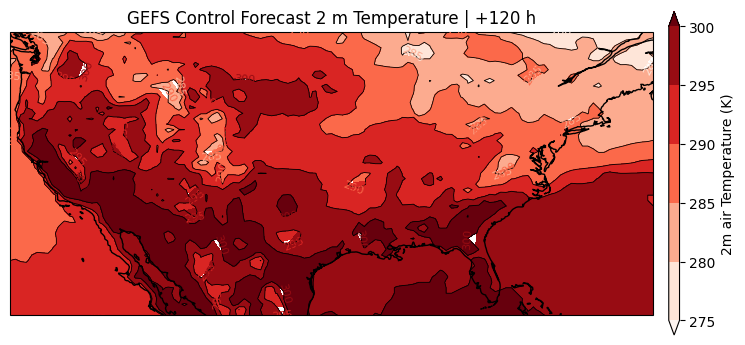

In [8]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))

contour_levels_temp = np.arange(275, 305, 5)
cs_temp = ax.contourf(test.longitude, test.latitude, test,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Reds', extend='both')
cs_temp_contour = ax.contour(test.longitude, test.latitude, test,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          colors='black',linewidths=0.6)

ax.coastlines()
plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

# Add title and colorbar, then show the plot
plt.title("GEFS Control Forecast 2 m Temperature | +120 h")

plt.colorbar(cs_temp, label='2m air Temperature (K)',
             pad=0.02, aspect=30,shrink=0.7)
plt.show()

###6.Compute ensemble spread for each lead time

In [9]:
lead_results = []

spread_maps = {}

for fhr in fhrs:
    print(f"\nProcessing forecast hour: {fhr}")

    member_list = []

    for member in members:
        da = open_gefs_t2m_member(init_date, cycle, member, fhr)
        da = da.expand_dims(member=[member])
        member_list.append(da)

    # Combine members into one DataArray
    ens = xr.concat(member_list, dim="member")

    # Ensemble mean and spread
    ens_mean = ens.mean(dim="member")
    ens_spread = ens.std(dim="member")

    # Store spread map
    spread_maps[fhr] = ens_spread

    # Area-weighted CONUS-average spread
    weights = np.cos(np.deg2rad(ens_spread.latitude))
    weights.name = "weights"

    conus_mean_spread = ens_spread.weighted(weights).mean(
        dim=("latitude", "longitude")
    )

    lead_results.append({
        "forecast_hour": fhr,
        "lead_day": fhr / 24,
        "conus_mean_spread_K": float(conus_mean_spread.values)
    })

spread_df = pd.DataFrame(lead_results)
spread_df


Processing forecast hour: 0
Using cached file: gec00.t00z.pgrb2a.0p50.f000
Using cached file: gep01.t00z.pgrb2a.0p50.f000
Using cached file: gep02.t00z.pgrb2a.0p50.f000
Using cached file: gep03.t00z.pgrb2a.0p50.f000
Using cached file: gep04.t00z.pgrb2a.0p50.f000
Using cached file: gep05.t00z.pgrb2a.0p50.f000
Using cached file: gep06.t00z.pgrb2a.0p50.f000
Using cached file: gep07.t00z.pgrb2a.0p50.f000
Using cached file: gep08.t00z.pgrb2a.0p50.f000
Using cached file: gep09.t00z.pgrb2a.0p50.f000
Using cached file: gep10.t00z.pgrb2a.0p50.f000


/tmp/ipykernel_85135/1661363078.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ens = xr.concat(member_list, dim="member")



Processing forecast hour: 24
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Using cached file: gep10.t00z.pgrb2a.0p50.f024


/tmp/ipykernel_85135/1661363078.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ens = xr.concat(member_list, dim="member")



Processing forecast hour: 48
Using cached file: gec00.t00z.pgrb2a.0p50.f048
Using cached file: gep01.t00z.pgrb2a.0p50.f048
Using cached file: gep02.t00z.pgrb2a.0p50.f048
Using cached file: gep03.t00z.pgrb2a.0p50.f048
Using cached file: gep04.t00z.pgrb2a.0p50.f048
Using cached file: gep05.t00z.pgrb2a.0p50.f048
Using cached file: gep06.t00z.pgrb2a.0p50.f048
Using cached file: gep07.t00z.pgrb2a.0p50.f048
Using cached file: gep08.t00z.pgrb2a.0p50.f048
Using cached file: gep09.t00z.pgrb2a.0p50.f048
Using cached file: gep10.t00z.pgrb2a.0p50.f048

Processing forecast hour: 72
Using cached file: gec00.t00z.pgrb2a.0p50.f072


...


Processing forecast hour: 96
Using cached file: gec00.t00z.pgrb2a.0p50.f096
Using cached file: gep01.t00z.pgrb2a.0p50.f096
Using cached file: gep02.t00z.pgrb2a.0p50.f096
Using cached file: gep03.t00z.pgrb2a.0p50.f096
Using cached file: gep04.t00z.pgrb2a.0p50.f096
Using cached file: gep05.t00z.pgrb2a.0p50.f096
Using cached file: gep06.t00z.pgrb2a.0p50.f096
Using cached file: gep07.t00z.pgrb2a.0p50.f096
Using cached file: gep08.t00z.pgrb2a.0p50.f096
Using cached file: gep09.t00z.pgrb2a.0p50.f096
Using cached file: gep10.t00z.pgrb2a.0p50.f096

Processing forecast hour: 120
Using cached file: gec00.t00z.pgrb2a.0p50.f120


/tmp/ipykernel_85135/1661363078.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ens = xr.concat(member_list, dim="member")


Using cached file: gep01.t00z.pgrb2a.0p50.f120
Using cached file: gep02.t00z.pgrb2a.0p50.f120
Using cached file: gep03.t00z.pgrb2a.0p50.f120
Using cached file: gep04.t00z.pgrb2a.0p50.f120
Using cached file: gep05.t00z.pgrb2a.0p50.f120
Using cached file: gep06.t00z.pgrb2a.0p50.f120
Using cached file: gep07.t00z.pgrb2a.0p50.f120
Using cached file: gep08.t00z.pgrb2a.0p50.f120
Using cached file: gep09.t00z.pgrb2a.0p50.f120
Using cached file: gep10.t00z.pgrb2a.0p50.f120


/tmp/ipykernel_85135/1661363078.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ens = xr.concat(member_list, dim="member")


,forecast_hour,lead_day,conus_mean_spread_K
0,0,0.0,0.391689
1,24,1.0,0.882184
2,48,2.0,0.964029
3,72,3.0,1.152477
4,96,4.0,1.342119
5,120,5.0,1.616236


###7.Plot spread growth with lead time

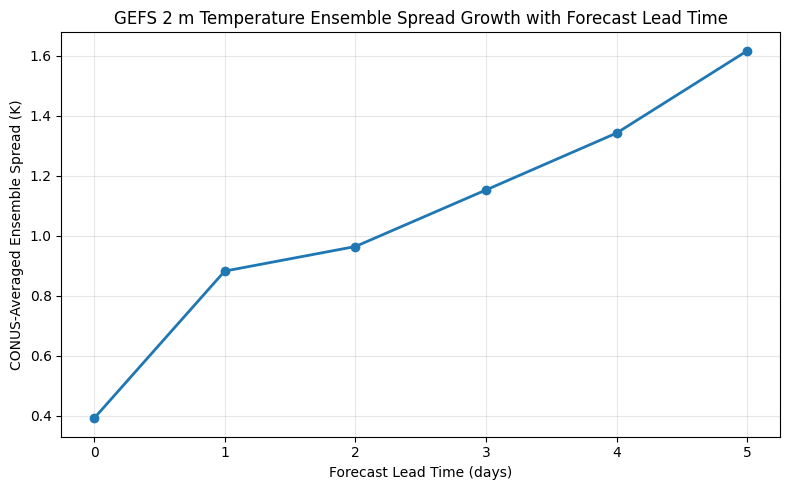

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    spread_df["lead_day"],
    spread_df["conus_mean_spread_K"],
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast Lead Time (days)")
plt.ylabel("CONUS-Averaged Ensemble Spread (K)")
plt.title("GEFS 2 m Temperature Ensemble Spread Growth with Forecast Lead Time")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Figure: CONUS-averaged GEFS 2 m temperature ensemble spread as a function of forecast lead time. Spread is calculated as the standard deviation across ensemble members and represents forecast uncertainty. Increasing spread with lead time indicates growing disagreement among ensemble members.

###8.Plot spatial spread map at +120h

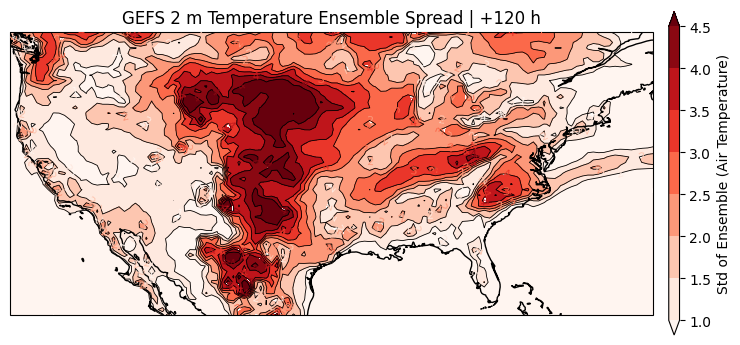

In [11]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))

fhr_plot = 120

ens_spared = spread_maps[fhr_plot]

contour_levels_temp = np.arange(1, 5, 0.5)
cs_temp = ax.contourf(ens_spread.longitude, ens_spread.latitude, ens_spread,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Reds', extend='both')
cs_temp_contour = ax.contour(ens_spread.longitude, ens_spread.latitude, ens_spread,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          colors='black',linewidths=0.6)

ax.coastlines()
plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

# Add title and colorbar, then show the plot
plt.title(f"GEFS 2 m Temperature Ensemble Spread | +{fhr_plot} h")

plt.colorbar(cs_temp, label='Std of Ensemble (Air Temperature)',
             pad=0.02, aspect=30,shrink=0.7)

plt.show()

## Note on AI Assistance

ChatGPT was used as a coding assistant for drafting and debugging portions of the Python workflow.
All scientific decisions, code review, and testing were performed by me.